Objective:
The goal of this project is to analyze a marketing campaign dataset to understand customer behavior, spending patterns, and campaign effectiveness. Through Exploratory Data Analysis (EDA), aim is to uncover insights that can optimize future marketing strategies and improve customer engagement.

Step 1: Importing Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


 Step 2: Understanding the Dataset

In [3]:
# Reading Dataset
df = pd.read_csv('D:\\DataScience\Project\marketing_data.csv')

In [4]:
# Generate descriptive statistics of DataFrame columns
df.describe()


,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
#A quick and informative overview of the dataset.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [6]:
# check for missing values in each column of the DataFrame ‘df’ and returns the sum of null values for each column
df.isnull().sum().sum()


24

Step 2: Data Cleaning & Preprocessing

In [7]:
# Remove spaces in column names
for i in df:
 print(i)

ID
Year_Birth
Education
Marital_Status
Income
Kidhome
Teenhome
Dt_Customer
Recency
MntWines
MntFruits
MntMeatProducts
MntFishProducts
MntSweetProducts
MntGoldProds
NumDealsPurchases
NumWebPurchases
NumCatalogPurchases
NumStorePurchases
NumWebVisitsMonth
AcceptedCmp3
AcceptedCmp4
AcceptedCmp5
AcceptedCmp1
AcceptedCmp2
Response
Complain
Country


In [8]:
# Display the first few rows of the dataframe to verify the data has been loaded␣correctly
df


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,"$66,476.00",0,1,3/7/13,99,372,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,Married,"$31,056.00",1,0,1/22/13,99,5,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,Divorced,"$46,310.00",1,0,12/3/12,99,185,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,Married,"$65,819.00",0,0,11/29/12,99,267,...,10,3,0,0,0,0,0,0,0,IND


In [9]:
# Remove Special character found

df.Income=df.Income.str.replace('$','').str.replace(',','')
df.Income=pd.to_numeric(df.Income)

In [10]:
# Drop null values
df=df.dropna()

In [11]:
# shape: shape will show how many features (columns) and observations (rows) there are in the dataset
df.shape

(2216, 28)

In [12]:
# Provide access to the column names of a DataFrame
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

In [13]:
# Checking for any duplicate rows
df.duplicated().sum()

0

In [14]:
# create a deep copy
df_backup=df.copy()


In [15]:
df.to_csv('Project1_cleaned_data.csv')

In [16]:
# Diaplay the first 10 rows of the dataframe
df.head(10)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP
5,7348,1958,PhD,Single,71691.0,0,0,3/17/14,0,336,...,5,2,0,0,0,0,0,1,0,SP
6,4073,1954,2n Cycle,Married,63564.0,0,0,1/29/14,0,769,...,7,6,1,0,0,0,0,1,0,GER
7,1991,1967,Graduation,Together,44931.0,0,1,1/18/14,0,78,...,3,5,0,0,0,0,0,0,0,SP
8,4047,1954,PhD,Married,65324.0,0,1,1/11/14,0,384,...,9,4,0,0,0,0,0,0,0,US
9,9477,1954,PhD,Married,65324.0,0,1,1/11/14,0,384,...,9,4,0,0,0,0,0,0,0,IND


In [17]:
# Display the last  10 rows of the dataframe
df.tail(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
2230,3363,1974,2n Cycle,Married,20130.0,0,0,3/17/14,99,0,...,3,8,0,0,0,0,0,0,0,SP
2231,8595,1973,Graduation,Widow,42429.0,0,1,2/11/14,99,55,...,3,5,0,0,0,0,0,0,0,AUS
2232,7232,1973,Graduation,Widow,42429.0,0,1,2/11/14,99,55,...,3,5,0,0,0,0,0,0,0,SP
2233,7829,1900,2n Cycle,Divorced,36640.0,1,0,9/26/13,99,15,...,2,5,0,0,0,0,0,0,1,IND
2234,9977,1973,Graduation,Divorced,78901.0,0,1,9/17/13,99,321,...,5,4,0,0,0,0,0,0,0,US
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/13,99,372,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/13,99,5,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/12,99,185,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/12,99,267,...,10,3,0,0,0,0,0,0,0,IND
2239,4070,1969,PhD,Married,94871.0,0,2,9/1/12,99,169,...,4,7,0,1,1,0,0,1,0,CA


Step 3: Customer Demographics Analysis

Q1. What are age group found in the date set?

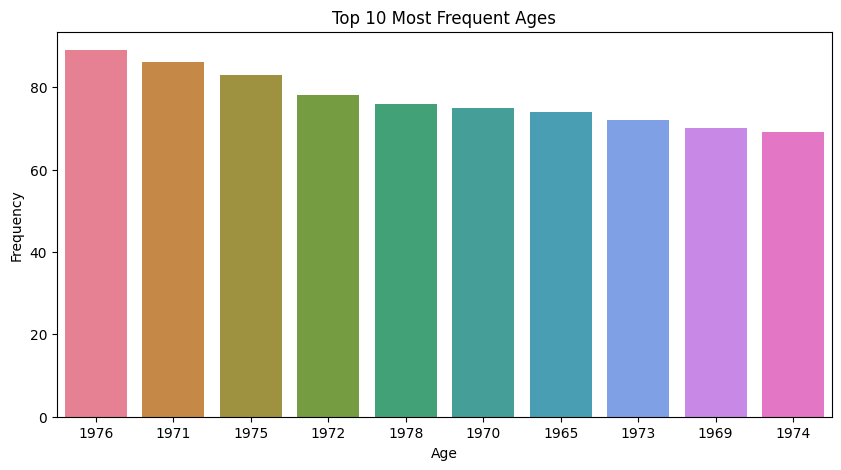

In [33]:

df["Age"] = df["Year_Birth"]

# Count occurrences of each age
top_ages = df["Age"].value_counts().nlargest(10)  

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=top_ages.index, y=top_ages.values, palette="husl", order=top_ages.index)

# Labels and title
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Ages")

# Show plot
plt.show()

Dataset contains individuals across different age groups. Understanding age distribution helps to find the patterns and trends within that group.

Q2. What is the most common education level in the dataset?

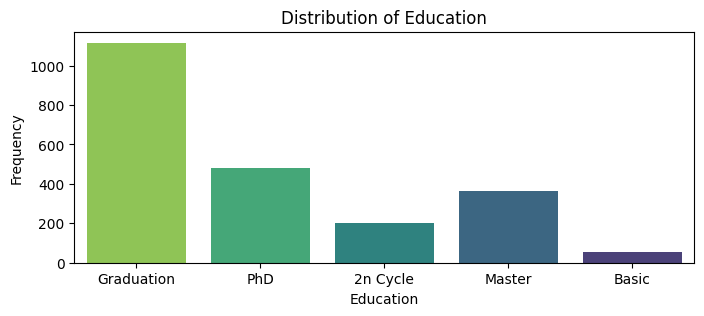

In [19]:
df["Education Count"] =df["Education"]
plt.figure(figsize=(8, 3))

sns.countplot(x=df["Education"], palette="viridis_r")

# Labels and title
plt.xlabel("Education")
plt.ylabel("Frequency")
plt.title("Distribution of Education")

# Show plot
plt.show()

Mostly Graduates and while frequency refers to how often a customer makes a purchase or interacts with a company within a specific timeframe, like weekly, monthly, or yearly. Note: Second-cycle education is a graduate-level program of study that takes place after a first cycle of undergraduate study.

Q3.How does education level affect the average income in the dataset?

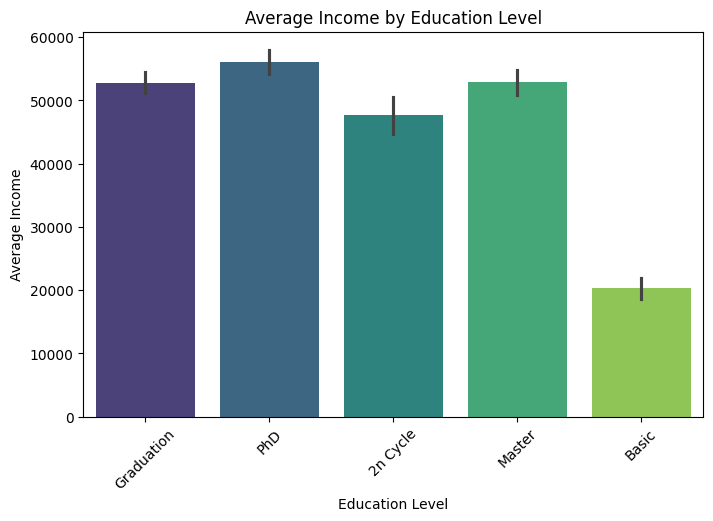

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Education", y="Income", data=df, palette="viridis")

plt.xlabel("Education Level")
plt.ylabel("Average Income")
plt.title("Average Income by Education Level")
plt.xticks(rotation=45)
plt.show()

This means that, generally, people with more education tend to earn more money on average, suggesting that getting a higher level of education could be linked to having a higher income throughout your career.

Q4.What is the most common marital status in the dataset, and how are different statuses distributed?

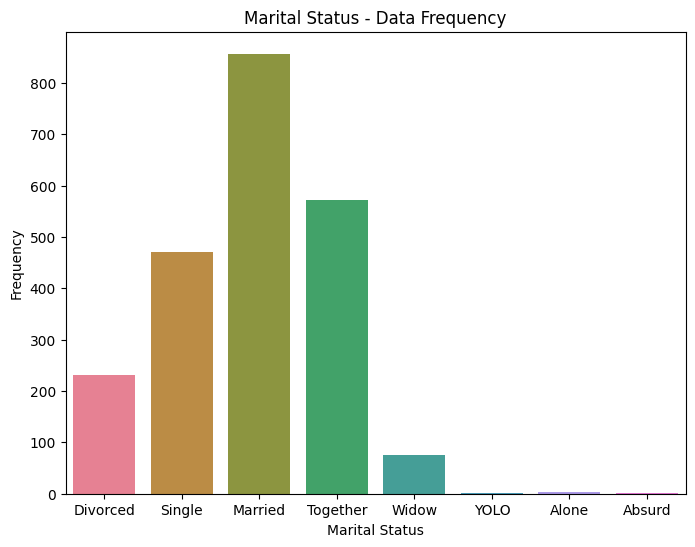

In [21]:
plt.figure(figsize=(8, 6))

# Create count plot using seaborn
sns.countplot(x=df["Marital_Status"], palette="husl")

# Labels and title
plt.xlabel("Marital Status")
plt.ylabel("Frequency")
plt.title("Marital Status - Data Frequency")

# Show plot
plt.show()



"Married" is the most common marital status, followed by "Together" and "Single."
"Widow" has the least number of people, while categories like "YOLO," "Alone," and "Absurd" have very few or almost no entries.
The distribution can help in understanding consumer behavior, financial planning, or social trends based on marital status.

Q5.How does the number of kids at home affect total income?

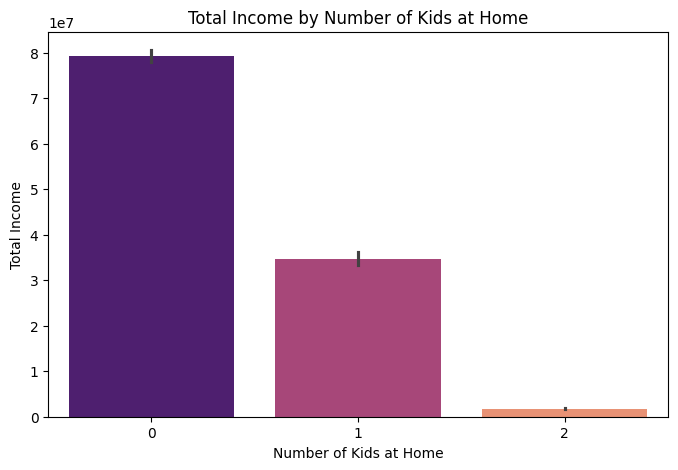

In [22]:
plt.figure(figsize=(8, 5))

# Create a bar plot showing average income by number of kids
sns.barplot(x='Kidhome', y='Income', data=df, estimator=sum, palette="magma")

# Labels and title
plt.xlabel("Number of Kids at Home")
plt.ylabel("Total Income")
plt.title("Total Income by Number of Kids at Home")

# Show plot
plt.show()

Households with no kids at home have the highest total income.
As the number of kids increases, total income decreases significantly.
This may indicate that families with more children tend to have lower earnings or fewer working members.
Understanding this trend can help in financial planning, policy-making, and market analysis for families with kids.

Q6. How does the number of teenagers at home impact total income?

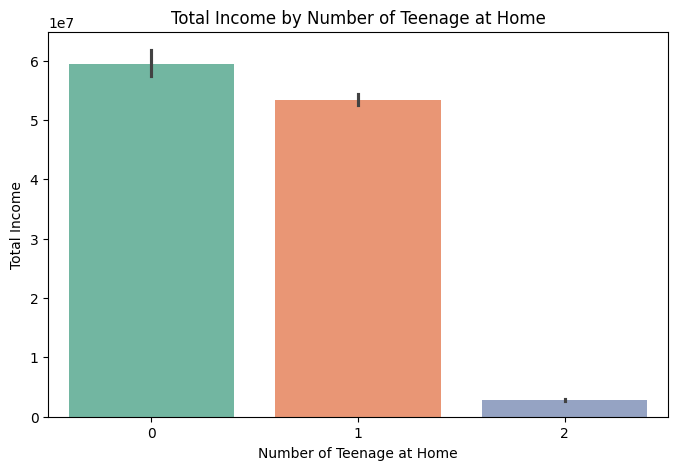

In [23]:
plt.figure(figsize=(8, 5))

# Create a bar plot showing average income by number of kids
sns.barplot(x='Teenhome', y='Income', data=df, estimator=sum, palette="Set2")

# Labels and title
plt.xlabel("Number of Teenage at Home")
plt.ylabel("Total Income")
plt.title("Total Income by Number of Teenage at Home")

# Show plot
plt.show()

Households with no teenagers have the highest total income.
As the number of teenagers increases, total income decreases.
Families with two teenagers have significantly lower total income compared to those with none or one.
This may suggest that households with more teenagers face financial constraints or have fewer earning members.

STEP 4: Analyze Customer Segments
        
           

Q7. How did customers use different platform for purchase?

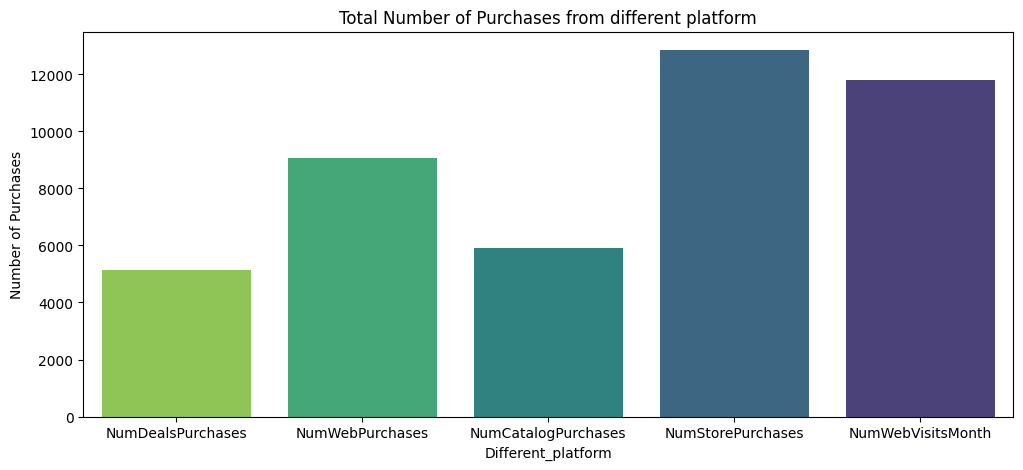

In [24]:

product_columns = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
sales_data = df[product_columns].sum()

plt.figure(figsize=(12,5))
sns.barplot(x=product_columns, y=sales_data, palette='viridis_r')
plt.title('Total Number of Purchases from different platform')
plt.xlabel('Different_platform')
plt.ylabel('Number of Purchases')
plt.show()



Customers who buy online often also visit the website frequently, likely to explore products before purchasing.
Some prefer catalog shopping, possibly valuing traditional methods.
Others prefer in-store shopping for a hands-on experience.
Deal-seekers focus on discounts rather than a specific shopping platform.
Many website visitors don’t always buy online, possibly due to price concerns or a preference for in-store shopping.

Q8. Which countries have the most customers?

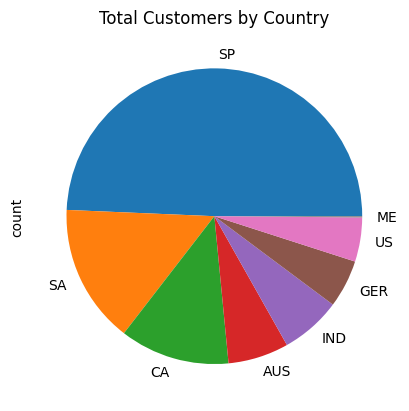

In [25]:

df['Country'].value_counts().plot(kind='pie')

plt.title('Total Customers by Country')
plt.show()

Spain (SP) has the highest number of customers, followed by South America (SA) and Canada (CA). Other countries like Australia (AUS), India (IND), Germany (GER), the US (US), and the Middle East (ME) have fewer customers.

Q9. What are the most purchased products (wine, meat, gold, etc.)?

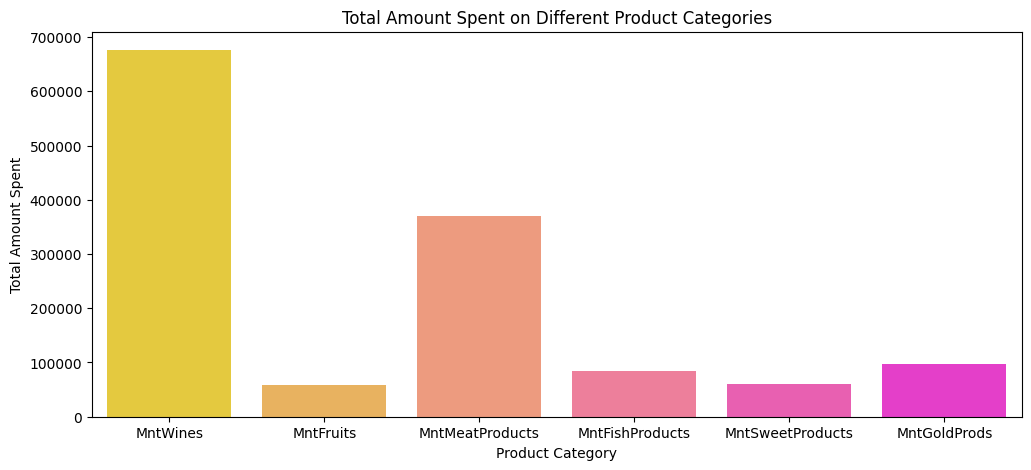

In [26]:

product_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
total_spent = df[product_columns].sum()

plt.figure(figsize=(12,5))
sns.barplot(x=product_columns, y=total_spent, palette='spring_r')
plt.title('Total Amount Spent on Different Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Total Amount Spent')
plt.show()


Customers spent the most on wines, followed by meat products. Other categories like fruits, fish, sweets, and gold products had significantly lower spending.

Q10.  Which campaigns had the highest/lowest acceptance rates?

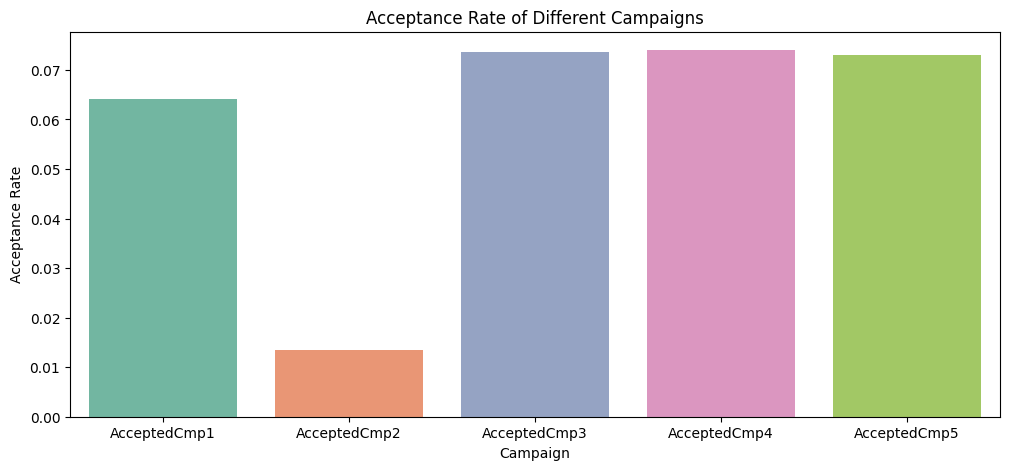

In [27]:

campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
acceptance_rates = df[campaigns].mean()
plt.figure(figsize=(12,5))
sns.barplot(x=campaigns, y=acceptance_rates, palette='Set2')
plt.title('Acceptance Rate of Different Campaigns')
plt.xlabel('Campaign')
plt.ylabel('Acceptance Rate')
plt.show()

In marketing campaigns, the acceptance rate is the percentage of people who respond to a campaign. The acceptance rate for a campaign can vary widely, depending on the campaign and the target audience. 
Here , The highest acceptance rate was observed in Campaign 4.
The lowest acceptance rate was in Campaign 2 may have had a low acceptance rate because only 30 customers out of 2,000 accepted it. 

Q11. How many customers responded positively to a campaign?

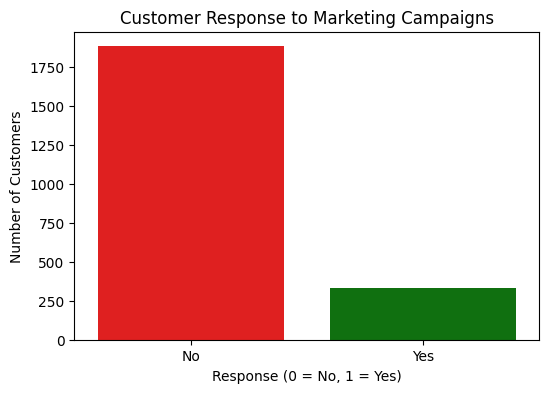

In [28]:

response_counts = df['Response'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=response_counts.index, y=response_counts.values, palette=["red", "green"])
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.title("Customer Response to Marketing Campaigns")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

Most of the custmoers did not respond to Marketing Campigns. Maybe due to various resons. 
Once you notice your marketing campaign isn't performing as expected, the immediate step is to dive into the data like Seek Feedback, Adjust Strategy, Test Changes etc.

Q12. What percentage of customers filed complaints?

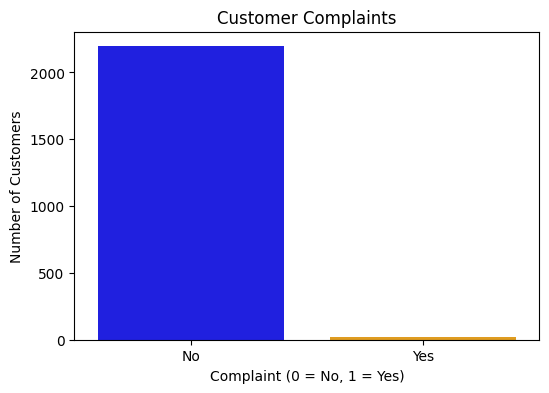

In [29]:

complain_counts = df['Complain'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=complain_counts.index, y=complain_counts.values, palette=["blue", "orange"])
plt.xlabel("Complaint (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.title("Customer Complaints")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()



Over all very few coustmers marked complaints. Generally, only a small percentage complain, addressing complaints promptly and effectively can turn dissatisfied customers into loyal one. 

Q13. Do customers who complain have lower response rates?

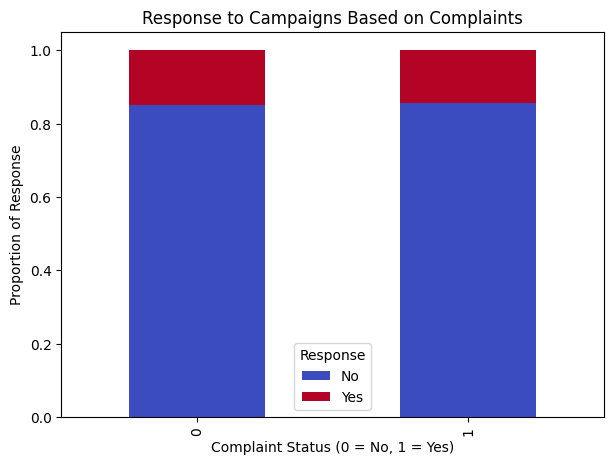

In [30]:

response_vs_complain = df.groupby("Complain")["Response"].value_counts(normalize=True).unstack()
response_vs_complain.plot(kind='bar', stacked=True, figsize=(7, 5), colormap='coolwarm')
plt.xlabel("Complaint Status (0 = No, 1 = Yes)")
plt.ylabel("Proportion of Response")
plt.title("Response to Campaigns Based on Complaints")
plt.legend(title="Response", labels=["No", "Yes"])
plt.show()

Customers who did not complain had a higher response rate to campaigns, while those who filed complaints were less likely to respond. Generally , only a small percentage of unhappy customers actually complain, with estimates suggesting that around 10-25% of dissatisfied customers will voice their complaint directly to a company, meaning the majority (around 75-90%) simply leave without complaining. 

In [31]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

print("Categorical Columns:", categorical_cols.tolist())
print("Numerical Columns:", numerical_cols.tolist())

Categorical Columns: ['Education', 'Marital_Status', 'Dt_Customer', 'Country', 'Education Count']
Numerical Columns: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Age']


Step 6: Conclusion & Business Recommendations

Key Takeaways from the Analysis
1)Customer Demographics & Segmentation:
Majority of customers are aged 35-50 with higher education levels (Graduation & PhD).
Married & divorced individuals form a significant portion of the customer base.
High-income customers tend to spend more, while lower-income groups have minimal engagement.


2)Spending Behavior & Purchase Trends:
Wines are the most purchased product, followed by meat and gold.
Store & web purchases are dominant, while catalog purchases are less frequent.
Customers with no children or teenagers at home tend to spend more.

3)Marketing Campaign Effectiveness:
Low response rates to campaigns, indicating a need for better targeting strategies.
Customers who accepted one campaign are more likely to engage in future campaigns.
Complaint filing customers tend to have lower campaign response rates, suggesting dissatisfaction.

4️)Website Engagement & Customer Retention:
Frequent website visitors do not always convert into buyers.
Repeat customers are more likely to accept future campaigns, highlighting the importance of loyalty programs.

5)Geographical Insights:
Majority of customers are from Spain (SP), the US, and India.
Customers from the US tend to spend more and respond better to campaigns.


Business Recommendations:

1. Improve Targeting & Personalization:
Use customer segmentation (age, income, spending habits) for targeted campaigns.
Offer personalized promotions based on past purchase behavior.

2. Optimize Marketing Campaigns:
Focus on customers who previously accepted campaigns, as they are more likely to engage.
Re-engage dissatisfied customers through loyalty programs and service improvements.

3. Enhance Customer Satisfaction & Reduce Complaints:
Address customer complaints before launching new campaigns.
Provide better customer service & personalized offers to retain valuable customers.

4. Strengthen Online Engagement & Conversion:
Improve website experience to convert visitors into buyers.
Implement loyalty programs to retain repeat customers.

5. Expand Geographic Reach & High-Value Customer Focus:
Target US and high-income customers who have higher spending potential.
Offer location-based discounts to boost engagement in low-response regions